In [6]:
import pandas as pd
df = pd.read_csv("spooky.csv")
#url = "https://github.com/GU4243-ADS/spring2018-project1-ginnyqg/raw/master/data/spooky.csv"
#df = pd.read_csv(url)


In [5]:
df.head(10)

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL
5,id22965,"A youth passed in solitude, my best years spen...",MWS
6,id09674,"The astronomer, perhaps, at this point, took r...",EAP
7,id13515,The surcingle hung in ribands from my body.,EAP
8,id19322,I knew that you could not say to yourself 'ste...,EAP
9,id00912,I confess that neither the structure of langua...,MWS


In [6]:
df.shape


(19579, 3)

In [7]:
#regex (expressions régulières)
import re

def remove_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)


In [8]:
test = "This is sooooo cooooool and amaaaazing!!!"
print(remove_repeated_chars(test))


This is soo cool and amaazing!!


In [9]:
df['text']= df['text'].apply(remove_repeated_chars)

In [10]:
df.tail(4)

,id,text,author
19575,id08973,The lids clenched themselves together as if in...,EAP
19576,id05267,"Mais il faut agir that is to say, a Frenchman ...",EAP
19577,id17513,"For an item of news like this, it strikes us i...",EAP
19578,id00393,"He laid a gnarled claw on my shoulder, and it ...",HPL


In [11]:
homoglyphs = {
    "$": "s",
    "@": "a",
    "0": "o",
    "1": "i",
    "3": "e",
    "5": "s"
}
def replace_homoglyphs(text):
    for symbol, letter in homoglyphs.items():
        text = text.replace(symbol, letter)
    return text


In [12]:
test = "$tupide is @mazing and c00l"
print(replace_homoglyphs(test))


stupide is amazing and cool


In [13]:
df['text'] = df['text'].apply(replace_homoglyphs)


✅ 3️⃣ Transformer URL, Email, HTML en forme canonique

In [14]:
def clean_special_entries(text):
    # Supprimer balises HTML
    text = re.sub(r'<.*?>', '', text)
    
    # Remplacer URLs
    text = re.sub(r'http\S+|www\S+', '<URL>', text)
    
    # Remplacer Emails
    text = re.sub(r'\S+@\S+', '<EMAIL>', text)
    
    return text


In [15]:
test = "Visit https://site.com or mail me at test@gmail.com <br> Hello!"
print(clean_special_entries(test))


Visit <URL> or mail me at <EMAIL>  Hello!


✅ 4️⃣ Mettre tous les caractères en minuscule

In [16]:
def to_lowercase(text):
    return text.lower()


In [17]:
test = "This Is GREAT!"
print(to_lowercase(test))


this is great!


In [18]:
df['text'] = df['text'].apply(to_lowercase)


✅ 5️⃣ Supprimer la ponctuation

In [19]:
import string
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))


In [20]:
test = "Hello!!! This is great, isn't it?"
print(remove_punctuation(test))


Hello This is great isnt it


In [21]:
df['text'] = df['text'].apply(remove_punctuation)


✅ 6️⃣ Supprimer les stopwords + mots de moins de 3 caractères

In [1]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english')).union(set(stopwords.words('french')))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def remove_stopwords_shortwords(text):
    # Split en mots
    words = text.split()
    # Filtrer
    cleaned_words = [w for w in words if w not in stop_words and len(w) >= 3]
    return " ".join(cleaned_words)


In [4]:
test = "This is a great example of NLP preprocessing because je mange  "
print(remove_stopwords_shortwords(test))


This great example NLP preprocessing mange


In [7]:
df['text'] = df['text'].apply(remove_stopwords_shortwords)


✅ 7️⃣ Correction orthographique avec pyspellchecker

In [26]:
#!pip install pyspellchecker


In [26]:
from spellchecker import SpellChecker

spell = SpellChecker()

In [27]:
def correct_spelling(text):
    words = text.split()
    corrected = []
    for w in words:
        c = spell.correction(w)
        if c is None:      # si pas de correction
            c = w           # garder le mot original
        corrected.append(c)
    return " ".join(corrected)


In [28]:
#def correct_spelling(text):
#    words = text.split()
#    corrected = [spell.correction(w) or w for w in words]  # si None → w
#    return " ".join(corrected)


In [29]:
test = " heello I am greeat and stupiid cool "
print(correct_spelling(test))


hello I am great and stupid cool


In [31]:
spell_fr = SpellChecker(language='fr')

In [32]:
def correct_spelling_fr(text):
    words = text.split()
    corrected = []
    for w in words:
        c = spell_fr.correction(w)
        if c is None:      # si pas de correction
            c = w           # garder le mot original
        corrected.append(c)
    return " ".join(corrected)


In [33]:
test = " jee veuu passer  "
print(correct_spelling_fr(test))


je veux passer


In [ ]:
#df['text_corrected'] = df['text'].apply(correct_spelling)
#df['text_corrected'] = df['text'].apply(correct_spelling_fr)


In [35]:

from langdetect import detect

text1 = "Bonjour tout le monde"
text2 = "I love programming"

print(detect(text1))  # 'fr'
print(detect(text2))  # 'en'

fr
it


In [36]:
from spellchecker import SpellChecker
from langdetect import detect

spell_en = SpellChecker(language='en')
spell_fr = SpellChecker(language='fr')

def correct_text(text):
    try:
        lang = detect(text)
    except:
        lang = 'en'  # par défaut
    words = text.split()
    corrected = []
    if lang == 'fr':
        for w in words:
            corrected.append(spell_fr.correction(w) or w)
    else:
        for w in words:
            corrected.append(spell_en.correction(w) or w)
    return " ".join(corrected)

In [37]:
df.loc[:9, 'text_corrected'] = df['text'].head(10).apply(correct_spelling)


In [32]:
df.head(3)

,id,text,author,text_corrected
0,id26305,process however afforded means ascertaining di...,EAP,process however afforded means ascertaining di...
1,id17569,never occurred fumbling might mere mistake,HPL,never occurred fumbling might mere mistake
2,id11008,left hand gold snuff box capered hill cutting ...,EAP,left hand gold snuff box capered hill cutting ...


 C. Segmentation
1️⃣ Segmenter chaque phrase sur espaces / ponctuation

In [46]:
import re 
def simple_tokenize(text):
    # Séparer sur espaces ou ponctuation
    tokens = re.findall(r'\b\w+\b', text)
    return tokens


In [47]:
test = "Hello,  this is great!"
print(simple_tokenize(test))


['Hello', 'this', 'is', 'great']


C.2 Segmentation par règles

🎯 Objectif

Découper le texte en tokens plus intelligents que juste espaces/ponctuation

Exemple de règles :

garder les contractions (don't, it's)

séparer les mots, chiffres, symboles spécifiques ($, %)

gérer les hashtags ou mentions (#AI, @user)

In [48]:
import nltk
nltk.download('punkt')  # nécessaire la première fois
from nltk.tokenize import word_tokenize


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [49]:
def rule_based_tokenize(text):
    return word_tokenize(text)


In [50]:
test = "Hello, world! It's 2026. #AI @ChatGPT ,Bonjour! Je m'appelle Hiba. J'adore NLP. Dr. Smith est mon prof. Pi vaut 3.14."
print(rule_based_tokenize(test))
print(simple_tokenize(test))

['Hello', ',', 'world', '!', 'It', "'s", '2026', '.', '#', 'AI', '@', 'ChatGPT', ',', 'Bonjour', '!', 'Je', "m'appelle", 'Hiba', '.', "J'adore", 'NLP', '.', 'Dr.', 'Smith', 'est', 'mon', 'prof.', 'Pi', 'vaut', '3.14', '.']
['Hello', 'world', 'It', 's', '2026', 'AI', 'ChatGPT', 'Bonjour', 'Je', 'm', 'appelle', 'Hiba', 'J', 'adore', 'NLP', 'Dr', 'Smith', 'est', 'mon', 'prof', 'Pi', 'vaut', '3', '14']


In [55]:
import re

def segmenter_phrases_personnalise(text):
    # Cas spécifiques : remplacer temporairement les points qui ne sont pas fin de phrase
    text = re.sub(r'\b(Dr|M|Mme)\.', r'\1<ABBR>', text)  # Dr., M., Mme.
    text = re.sub(r'(\d)\.(\d)', r'\1<NUM>\2', text)     # nombres décimaux
    
    # Séparer par ponctuation finale
    phrases = re.split(r'(?<=[.!?])\s+', text)
    
    # Restaurer les abréviations et nombres
    phrases = [p.replace('<ABBR>', '.').replace('<NUM>', '.') for p in phrases]
    
    return phrases

texte = "Bonjour! Je m'appelle Hiba. J'adore Python Dr. Smith est mon professeur. Pi vaut 3.14."
phrases = segmenter_phrases_personnalise(texte)

print(phrases)


['Bonjour!', "Je m'appelle Hiba.", "J'adore Python Dr. Smith est mon professeur.", 'Pi vaut 3.14.']


In [56]:
import spacy
nlp = spacy.load("en_core_web_sm")

tokens_subword = [[t.text for t in nlp(sent)] for sent in df["text"].head(10)]
tokens_subword


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.2). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


[['This',
  'process',
  ',',
  'however',
  ',',
  'afforded',
  'means',
  'ascertaining',
  'dimensions',
  'dungeon',
  ';',
  'might',
  'make',
  'circuit',
  ',',
  'return',
  'point',
  'whence',
  'set',
  'out',
  ',',
  'without',
  'aware',
  'fact',
  ';',
  'perfectly',
  'uniform',
  'seemed',
  'wall',
  '.'],
 ['never', 'occurred', 'fumbling', 'might', 'mere', 'mistake', '.'],
 ['left',
  'hand',
  'gold',
  'snuff',
  'box',
  ',',
  'which',
  ',',
  'capered',
  'hill',
  ',',
  'cutting',
  'manner',
  'fantastic',
  'steps',
  ',',
  'took',
  'snuff',
  'incessantly',
  'air',
  'greatest',
  'possible',
  'self',
  'satisfaction',
  '.'],
 ['How',
  'lovely',
  'spring',
  'looked',
  'Windsor',
  'Terrace',
  'sixteen',
  'fertile',
  'counties',
  'spread',
  'beneath',
  ',',
  'speckled',
  'happy',
  'cottages',
  'wealthier',
  'towns',
  ',',
  'looked',
  'former',
  'years',
  ',',
  'heart',
  'cheering',
  'fair',
  '.'],
 ['Finding',
  'nothing',
  

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text = "unhappiness"
tokens = tokenizer.tokenize(text)
print(tokens)


In [ ]:
#df['tokens'] = df['text_corrected'].apply(simple_tokenize)
#df['tokens_rule'] = df['text_corrected'].apply(rule_based_tokenize)
#df['subword_tokens'] = df['text_corrected'].apply(lambda x: tokenizer.tokenize(x))


non-BERT tokenizers:

In [ ]:
#!pip install tokenizers
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Create a BPE tokenizer
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Train on a corpus (list of sentences)
trainer = trainers.BpeTrainer(vocab_size=1000)
tokenizer.train(["text.txt"], trainer)

tokens = tokenizer.encode("unhappiness").tokens
print(tokens)


D. Reconnaissance d’Entités Nommées (NER)

1️⃣ Extraction PERSON / ORG / GPE / DATE

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

texts = df["text"].head(50)

entities = []

for text in texts:
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE", "DATE"]:
            entities.append((ent.text, ent.label_))

print(entities[:20])

In [ ]:
from collections import defaultdict, Counter

author_entities = defaultdict(list)

for i, row in df.head(50).iterrows():
    doc = nlp(row["text"])
    author = row["author"]
    
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE", "DATE"]:
            author_entities[author].append(ent.text)

for author, ents in author_entities.items():
    print(f"\nAuteur : {author}")
    print(Counter(ents).most_common(5))

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

all_entities = [ent[0] for ent in entities]

entity_freq = Counter(all_entities)
top10 = entity_freq.most_common(10)

names = [x[0] for x in top10]
counts = [x[1] for x in top10]

plt.figure()
plt.bar(names, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Entités Globales")
plt.show()

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('wordnet')
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
text = "running jumped happily cats"

tokens = word_tokenize(text)

# Stemming
stemmed = [stemmer.stem(w) for w in tokens]
print("Stemmed:", stemmed)
# Output: ['run', 'jump', 'happili', 'cat']

# Lemmatization
lemmatized = [lemmatizer.lemmatize(w) for w in tokens]
print("Lemmatized:", lemmatized)
# Output: ['running', 'jumped', 'happily', 'cat']


| Méthode             | Principe                            | Exemple (*running*) | Avantages              | Inconvénients                  |
| ------------------- | ----------------------------------- | ------------------- | ---------------------- | ------------------------------ |
| **NLTK Stem**       | Coupe les suffixes (règles simples) | `run`               | Très rapide            | Pas linguistique, parfois faux |
| **NLTK Lemmatize**  | Basée sur dictionnaire + POS        | `run`               | Plus correcte que stem | Besoin du POS                  |
| **spaCy Lemmatize** | Contextuelle (POS + modèle)         | `run`               | ⭐ Plus précise         | Plus lourde                    |


In [ ]:
df['tokens'] = df['text'].apply(word_tokenize)
df['stemmed'] = df['tokens'].apply(lambda lst: [stemmer.stem(w) for w in lst])
df['lemmatized'] = df['tokens'].apply(lambda lst: [lemmatizer.lemmatize(w) for w in lst])


In [ ]:
df_100 = df.head(100).copy()
df_100['spacy_lemma'] = df_100['text'].apply(lambda x: [token.lemma_ for token in nlp(x)])


In [43]:
import pandas as pd

# chercher "great" sans tenir compte des majuscules
df["contains_great"] = df["text"].str.contains(r"\bgreat\b", case=False, na=False)

great_counts = df[df["contains_great"]].groupby("author").size()

great_counts

author
EAP    212
HPL    179
MWS     86
dtype: int64

In [44]:
#!pip install pywaffle

Great:
 author
EAP    212
HPL    179
MWS     86
dtype: int64

Impossible:
 author
EAP    62
HPL    16
MWS    19
dtype: int64


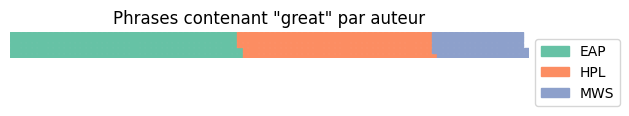

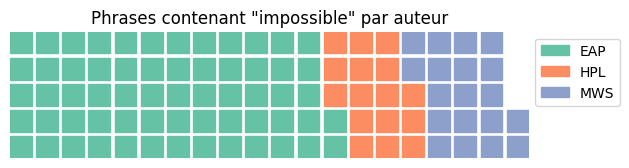

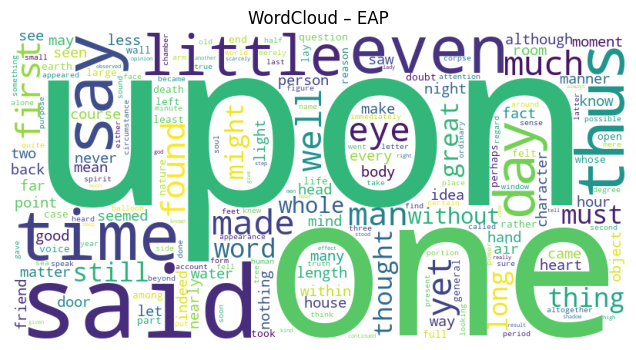

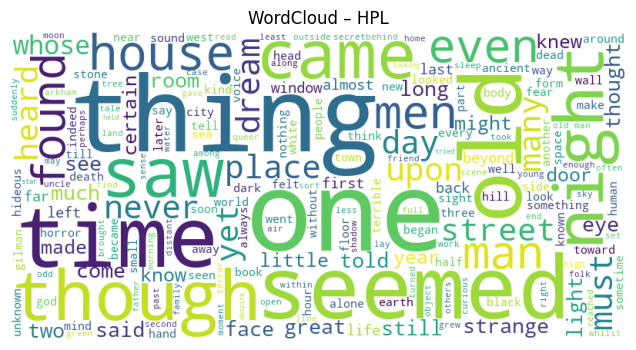

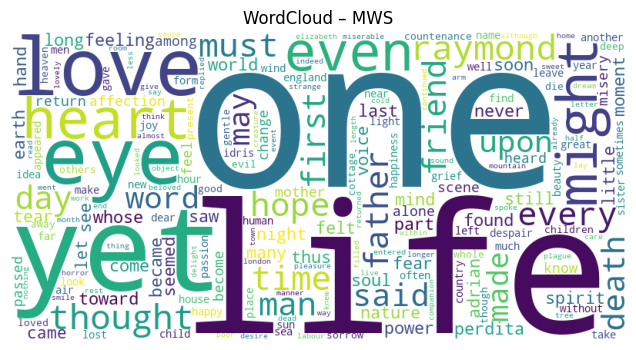

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


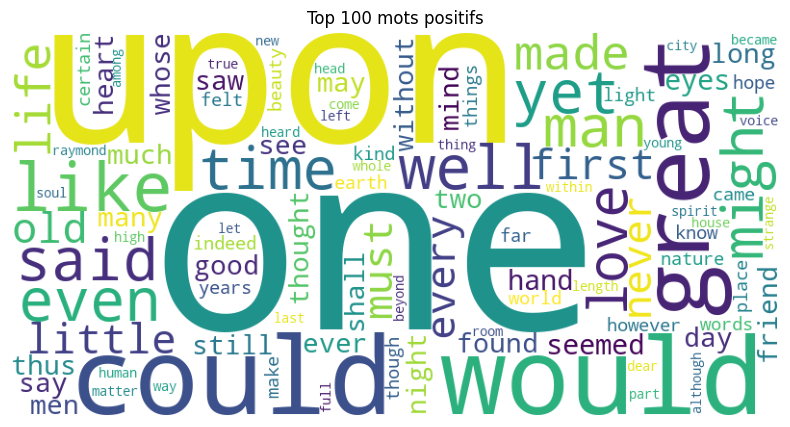

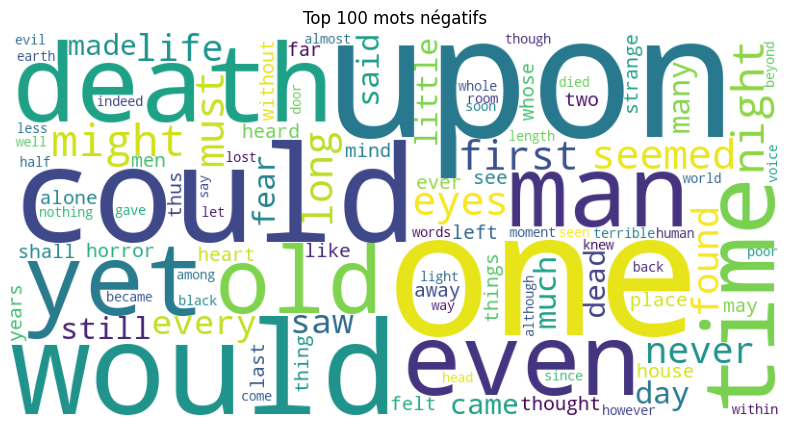

In [50]:
# =========================
# F. ANALYSE DES FRÉQUENCES
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# -------------------------
# 1 & 2. GREAT / IMPOSSIBLE
# -------------------------

def count_word_by_author(df, word):
    mask = df["text"].str.contains(fr"\b{word}\b", case=False, na=False)
    return df[mask].groupby("author").size()

great_counts = count_word_by_author(df, "great")
impossible_counts = count_word_by_author(df, "impossible")

print("Great:\n", great_counts)
print("\nImpossible:\n", impossible_counts)

# -------------------------
# PyWaffle (if available)
# -------------------------
try:
    from pywaffle import Waffle

    fig = plt.figure(
        FigureClass=Waffle,
        rows=5,
        values=great_counts.to_dict(),
        title={'label': 'Phrases contenant "great" par auteur', 'loc': 'center'},
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
    )
    plt.show()

    fig = plt.figure(
        FigureClass=Waffle,
        rows=5,
        values=impossible_counts.to_dict(),
        title={'label': 'Phrases contenant "impossible" par auteur', 'loc': 'center'},
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
    )
    plt.show()

except:
    # Fallback accepté si PyWaffle non installé
    great_counts.plot(kind="bar", title='Phrases contenant "great"')
    plt.show()

    impossible_counts.plot(kind="bar", title='Phrases contenant "impossible"')
    plt.show()

# -------------------------
# 3. WordCloud par auteur
# -------------------------

for author in df["author"].unique():
    text = " ".join(df[df["author"] == author]["text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"WordCloud – {author}")
    plt.show()

# -------------------------
# 4. Top 100 mots positifs / négatifs
# -------------------------

nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

positive_words = []
negative_words = []

for text in df["text"]:
    score = sia.polarity_scores(text)["compound"]
    words = text.lower().split()

    if score > 0:
        positive_words.extend(words)
    elif score < 0:
        negative_words.extend(words)

top_positive = dict(Counter(positive_words).most_common(100))
top_negative = dict(Counter(negative_words).most_common(100))

wc_pos = WordCloud(width=800, height=400, background_color="white")\
    .generate_from_frequencies(top_positive)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Top 100 mots positifs")
plt.show()

wc_neg = WordCloud(width=800, height=400, background_color="white")\
    .generate_from_frequencies(top_negative)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Top 100 mots négatifs")
plt.show()
